# 01 业务理解：Olist 电商数据结构与业务概览

## 目标

在进入具体分析之前，先回答以下问题：

1. Olist 平台的整体规模有多大？
2. 数据覆盖了哪些业务实体？它们之间如何关联？
3. 哪些品类卖得最好？为什么？
4. `customer_id` 和 `customer_unique_id` 的区别是什么？为什么这对后续分析至关重要？
5. 订单状态和时间范围是怎样的？

> 产出：`docs/01_business_understanding.md`

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np

matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

con = duckdb.connect()
print("✅ 环境准备完成")

✅ 环境准备完成


In [2]:
# ============================================================
# 1. 数据规模总览
# ============================================================

tables_info = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

rows_data = []
for name, fname in tables_info.items():
    cnt = con.sql(f"SELECT COUNT(*) FROM '../data/raw/{fname}'").fetchone()[0]
    cols = con.sql(f"SELECT * FROM '../data/raw/{fname}' LIMIT 0").columns
    rows_data.append({'表名': name, '行数': cnt, '列数': len(cols), '关键列': ', '.join(cols[:8])})

df_overview = pd.DataFrame(rows_data)
df_overview

,表名,行数,列数,关键列
0,customers,99441,5,"customer_id, customer_unique_id, customer_zip_..."
1,geolocation,1000163,5,"geolocation_zip_code_prefix, geolocation_lat, ..."
2,order_items,112650,7,"order_id, order_item_id, product_id, seller_id..."
3,order_payments,103886,5,"order_id, payment_sequential, payment_type, pa..."
4,order_reviews,99224,7,"review_id, order_id, review_score, review_comm..."
5,orders,99441,8,"order_id, customer_id, order_status, order_pur..."
6,products,32951,9,"product_id, product_category_name, product_nam..."
7,sellers,3095,4,"seller_id, seller_zip_code_prefix, seller_city..."
8,category_translation,71,2,"product_category_name, product_category_name_e..."


## 数据规模速览

| 表 | 行数 | 说明 |
|---|---|---|
| orders | 99,441 | 订单表（与 customers 一一对应） |
| customers | 99,441 | 客户表（每行一个订单级身份） |
| order_items | 112,650 | 订单商品明细 |
| order_payments | 103,886 | 支付记录 |
| order_reviews | 99,224 | 评价记录 |
| products | 32,951 | 商品信息 |
| sellers | 3,095 | 卖家信息 |
| geolocation | 1,000,163 | 巴西邮编地理坐标 |
| category_translation | 71 | 品类葡语→英语翻译 |

**关键发现**：
- 订单数约 10 万，这是一个中等规模的电商数据集，适合做全量分析
- 商品数 (32,951) 远多于活跃卖家数 (3,095)，平均每个卖家上架约 10 个商品
- 品类翻译表只有 71 条，73 个品类中有 2 个未被翻译覆盖

In [3]:
# ============================================================
# 2. 数据关系图（文字版）
# ============================================================

print("""
+====================================================================+
|                    Olist 数据集关系图                                |
+====================================================================+
|                                                                     |
|  customers ----(customer_id)----> orders                            |
|                                     |                               |
|                       +-------------+-------------+                 |
|                       |             |             |                 |
|                 order_items   order_payments  order_reviews         |
|                  |       |                                         |
|             (product_id) (seller_id)                                |
|                  |       |                                         |
|              products  sellers                                      |
|                  |       |                                         |
|       category_translation  |                                       |
|                              |                                      |
|  geolocation --(zip_code_prefix)-- customers / sellers              |
|                                                                     |
|  !! 关键陷阱：                                                       |
|  * customer_id 是订单级身份（1订单1个），customer_unique_id          |
|    才是真实用户身份（复购/留存分析必须用后者）                        |
|  * 一个 order 可能有多条 order_items / payments / reviews             |
|  * geolocation 通过 zip_code_prefix 关联，同一 prefix 多条记录       |
+====================================================================+
""")


+====================================================================+
|                    Olist 数据集关系图                                |
+====================================================================+
|                                                                     |
|  customers ----(customer_id)----> orders                            |
|                                     |                               |
|                       +-------------+-------------+                 |
|                       |             |             |                 |
|                 order_items   order_payments  order_reviews         |
|                  |       |                                         |
|             (product_id) (seller_id)                                |
|                  |       |                                         |
|              products  sellers                                      |
|                  |       |                                         |
|

In [4]:
# ============================================================
# 3. 订单状态分布
# ============================================================

status_df = con.sql("""
    SELECT order_status,
           COUNT(*) as cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct
    FROM '../data/raw/olist_orders_dataset.csv'
    GROUP BY order_status
    ORDER BY cnt DESC
""").df()

status_df

,order_status,cnt,pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


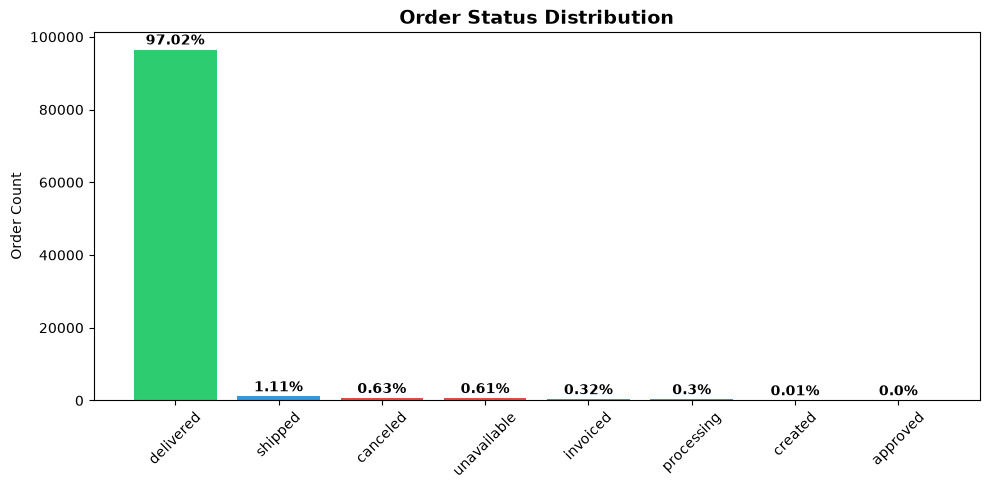

✅ 图表已保存至 reports/01_order_status_distribution.png


In [5]:
# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
cmap = {'delivered': '#2ecc71', 'canceled': '#e74c3c', 'unavailable': '#e74c3c'}
colors = [cmap.get(s, '#3498db') for s in status_df['order_status']]
bars = ax.bar(status_df['order_status'], status_df['cnt'], color=colors)
for bar, pct in zip(bars, status_df['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Order Status Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/01_order_status_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/01_order_status_distribution.png")

### 订单状态解读

- **97.02%** 的订单最终送达（delivered），平台履约能力良好
- **0.63%** 取消（canceled）+ **0.61%** 不可用（unavailable）= 约 1.24% 的订单未完成
- 漏斗分析和 GMV 计算时，通常只使用 `delivered` 状态的订单
- 注意：`approved` 状态仅 2 条，说明数据集中订单审批几乎是瞬间完成的

数据时间范围：2016-09-04 21:15:19  ~  2018-10-17 17:30:18
覆盖时长：约 25 个月


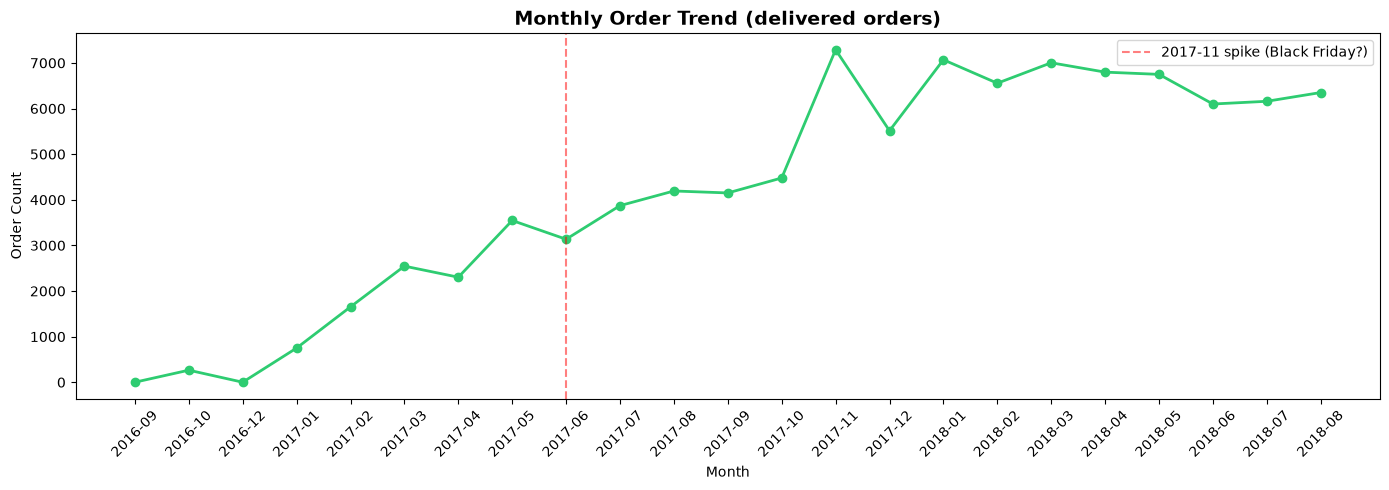

✅ 图表已保存至 reports/01_monthly_order_trend.png


In [6]:
# ============================================================
# 4. 时间范围与月度趋势
# ============================================================

time_range = con.sql("""
    SELECT MIN(order_purchase_timestamp), MAX(order_purchase_timestamp)
    FROM '../data/raw/olist_orders_dataset.csv'
""").fetchone()
print(f"数据时间范围：{time_range[0]}  ~  {time_range[1]}")
print(f"覆盖时长：约 25 个月")

monthly = con.sql("""
    SELECT STRFTIME(CAST(order_purchase_timestamp AS TIMESTAMP), '%Y-%m') as month,
           COUNT(*) as order_cnt
    FROM '../data/raw/olist_orders_dataset.csv'
    WHERE order_status = 'delivered'
    GROUP BY month ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['month'], monthly['order_cnt'], marker='o', color='#2ecc71', linewidth=2)
ax.set_title('Monthly Order Trend (delivered orders)', fontsize=14, fontweight='bold')
ax.set_ylabel('Order Count')
ax.set_xlabel('Month')
ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='2017-11 spike (Black Friday?)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/01_monthly_order_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/01_monthly_order_trend.png")

### 时间趋势解读

- 数据从 2016 年 9 月开始，但前 3 个月几乎无数据（2016-09 仅 1 单，2016-11 无数据），平台实际运营从 2017 年 1 月开始
- 2017 年快速爬坡，从每月 ~750 单增长到 11 月的 ~7,289 单（可能是黑五促销）
- 2018 年稳定在月均 ~6,500 单左右，进入平台期
- **分析时建议使用 2017-01 至 2018-08 的数据**，避免早期数据噪音

In [7]:
# ============================================================
# 5. 品类分析：哪些品类卖得最好？
# ============================================================

cat_df = con.sql("""
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name) as category,
        COUNT(DISTINCT oi.order_id) as order_cnt,
        ROUND(SUM(oi.price), 2) as total_revenue,
        ROUND(AVG(oi.price), 2) as avg_price,
        COUNT(DISTINCT oi.product_id) as product_cnt
    FROM '../data/raw/olist_order_items_dataset.csv' oi
    JOIN '../data/raw/olist_products_dataset.csv' p ON oi.product_id = p.product_id
    LEFT JOIN '../data/raw/product_category_name_translation.csv' t
        ON p.product_category_name = t.product_category_name
    GROUP BY 1
    ORDER BY order_cnt DESC
    LIMIT 20
""").df()

cat_df

,category,order_cnt,total_revenue,avg_price,product_cnt
0,bed_bath_table,9417,1036988.68,93.30,3029
1,health_beauty,8836,1258681.34,130.16,2444
2,sports_leisure,7720,988048.97,114.34,2867
3,computers_accessories,6689,911954.32,116.51,1639
4,furniture_decor,6449,729762.49,87.56,2657
5,housewares,5884,632248.66,90.79,2335
6,watches_gifts,5624,1205005.68,201.14,1329
7,telephony,4199,323667.53,71.21,1134
8,auto,3897,592720.11,139.96,1900
9,toys,3886,483946.60,117.55,1411


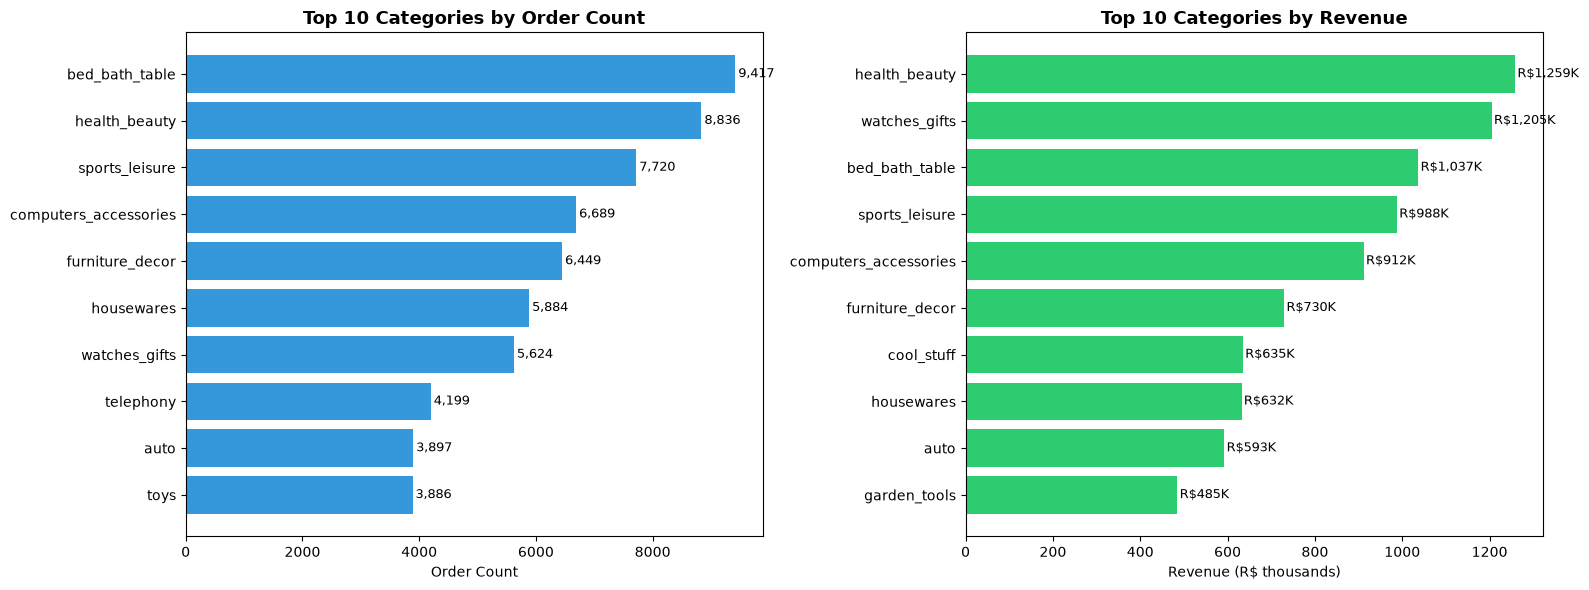

✅ 图表已保存至 reports/01_top_categories.png


In [8]:
# 可视化 Top 10 品类
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = cat_df.head(10)

ax1 = axes[0]
bars1 = ax1.barh(range(len(top10)), top10['order_cnt'].values, color='#3498db')
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels(top10['category'].values)
ax1.invert_yaxis()
ax1.set_title('Top 10 Categories by Order Count', fontsize=13, fontweight='bold')
ax1.set_xlabel('Order Count')
for i, (bar, v) in enumerate(zip(bars1, top10['order_cnt'].values)):
    ax1.text(v + 50, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=9)

top10_rev = cat_df.nlargest(10, 'total_revenue')
ax2 = axes[1]
bars2 = ax2.barh(range(len(top10_rev)), top10_rev['total_revenue'].values / 1000, color='#2ecc71')
ax2.set_yticks(range(len(top10_rev)))
ax2.set_yticklabels(top10_rev['category'].values)
ax2.invert_yaxis()
ax2.set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
ax2.set_xlabel('Revenue (R$ thousands)')
for i, (bar, v) in enumerate(zip(bars2, top10_rev['total_revenue'].values)):
    ax2.text(v/1000 + 5, bar.get_y() + bar.get_height()/2, f'R${v/1000:,.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/01_top_categories.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/01_top_categories.png")

### 品类分析解读

**按订单量 Top 3：**
1. **bed_bath_table**（床/浴室/桌）：9,417 单，R$1.04M → 家居日用品，高频刚需
2. **health_beauty**（健康美妆）：8,836 单，R$1.26M → 快消品，复购潜力大
3. **sports_leisure**（运动休闲）：7,720 单，R$0.99M → 生活方式品类

**按 GMV Top 3：**
1. **health_beauty**：R$1.26M（均价 R$142.41）
2. **watches_gifts**（手表礼品）：R$1.21M（仅 5,624 单，均价 R$214.27）→ 高客单价品类
3. **bed_bath_table**：R$1.04M

**关键洞察**：
- **watches_gifts** 订单量排第 7，但 GMV 排第 2 → 高客单价 + 高转化价值的品类，值得重点关注
- **telephony**（通讯）订单量排第 8 (4,199 单)，但 GMV 仅排第 14 → 低客单价，可能是配件类
- 前 10 品类贡献了大部分订单和 GMV，符合电商长尾分布的典型特征

In [9]:
# ============================================================
# 6. !! 关键概念：customer_id vs customer_unique_id
# ============================================================

print("=" * 60)
print("customer_id vs customer_unique_id —— 本项目最重要的概念")
print("=" * 60)

r = con.sql("""
    SELECT
        COUNT(DISTINCT customer_id) as distinct_customer_ids,
        COUNT(DISTINCT customer_unique_id) as distinct_unique_ids,
        COUNT(*) as total_rows
    FROM '../data/raw/olist_customers_dataset.csv'
""").fetchone()

print(f"\n客户表统计：")
print(f"  customer_id 去重数：{r[0]:,}")
print(f"  customer_unique_id 去重数：{r[1]:,}")
print(f"  总行数：{r[2]:,}")
print(f"  → 有 {r[0] - r[1]:,} 个 customer_id 属于重复用户")

dup_customers = con.sql("""
    SELECT customer_unique_id, COUNT(DISTINCT customer_id) as id_count
    FROM '../data/raw/olist_customers_dataset.csv'
    GROUP BY customer_unique_id
    HAVING COUNT(DISTINCT customer_id) > 1
    ORDER BY id_count DESC
""").df()

print(f"\n重复购买用户分布：")
print(f"  有多个 customer_id 的 unique 用户：{len(dup_customers):,}")
print(f"  最多购买次数：{dup_customers['id_count'].max()}")
print(f"  平均购买次数：{dup_customers['id_count'].mean():.2f}")

print(f"\n!! 如果用 customer_id 做复购分析：")
print(f"  每个 customer_id 只对应 1 个订单 → 复购率 = 0%")
print(f"  但真实情况是：{len(dup_customers):,} 个用户购买了多次")
print(f"  → 这就是为什么 '人人都是1次' 是一个失真结果")

customer_id vs customer_unique_id —— 本项目最重要的概念

客户表统计：
  customer_id 去重数：99,441
  customer_unique_id 去重数：96,096
  总行数：99,441
  → 有 3,345 个 customer_id 属于重复用户

重复购买用户分布：
  有多个 customer_id 的 unique 用户：2,997
  最多购买次数：17
  平均购买次数：2.12

!! 如果用 customer_id 做复购分析：
  每个 customer_id 只对应 1 个订单 → 复购率 = 0%
  但真实情况是：2,997 个用户购买了多次
  → 这就是为什么 '人人都是1次' 是一个失真结果


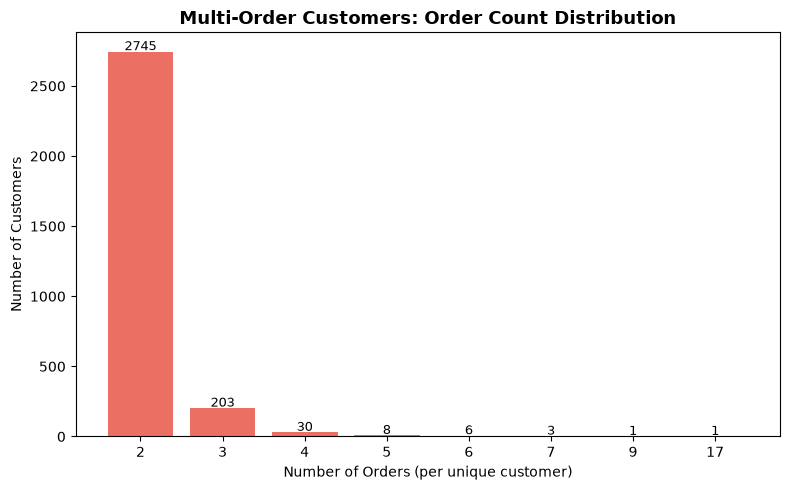

✅ 图表已保存至 reports/01_multi_order_distribution.png


In [10]:
# 可视化重复购买次数分布
fig, ax = plt.subplots(figsize=(8, 5))
freq_dist = dup_customers['id_count'].value_counts().sort_index()
ax.bar(freq_dist.index.astype(str), freq_dist.values, color='#e74c3c', alpha=0.8)
ax.set_title('Multi-Order Customers: Order Count Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders (per unique customer)')
ax.set_ylabel('Number of Customers')
for i, v in enumerate(freq_dist.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/01_multi_order_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/01_multi_order_distribution.png")

### customer_id vs customer_unique_id 的结论

这是一个**数据建模层面的关键决策**，直接影响后续所有用户分析的准确性：

| 场景 | 使用哪个 ID | 原因 |
|---|---|---|
| 订单级分析（漏斗、GMV、客单价） | customer_id | 每个订单一个 customer_id |
| 用户级分析（复购率、留存、RFM） | **customer_unique_id** | 这才是真实的人 |
| 用户画像 | customer_unique_id | 需要聚合该用户所有订单 |

**数据事实**：
- 99,441 个 customer_id → 96,096 个 customer_unique_id
- 3,345 个用户有多个 customer_id（即重复购买）
- 只用 customer_id 分析 = 抹杀所有复购行为 → 错误结论

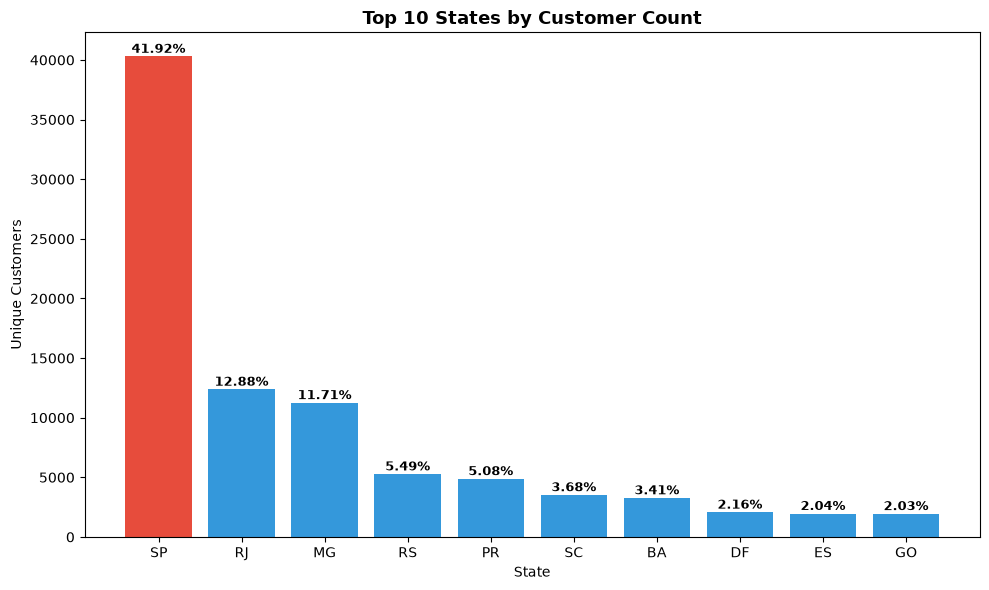

✅ 图表已保存至 reports/01_state_distribution.png

SP（圣保罗）占 41.92% 的用户，集中度极高


In [11]:
# ============================================================
# 7. 地理分布
# ============================================================

state_df = con.sql("""
    SELECT customer_state,
           COUNT(DISTINCT customer_unique_id) as customer_cnt,
           ROUND(COUNT(DISTINCT customer_unique_id) * 100.0
               / SUM(COUNT(DISTINCT customer_unique_id)) OVER(), 2) as pct
    FROM '../data/raw/olist_customers_dataset.csv'
    GROUP BY customer_state
    ORDER BY customer_cnt DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
top10 = state_df.head(10)
colors = ['#e74c3c' if s == 'SP' else '#3498db' for s in top10['customer_state']]
ax.bar(top10['customer_state'], top10['customer_cnt'], color=colors)
ax.set_title('Top 10 States by Customer Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Unique Customers')
ax.set_xlabel('State')
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(i, row['customer_cnt'] + 300, f"{row['pct']}%", ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_state_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/01_state_distribution.png")
print(f"\nSP（圣保罗）占 {top10.iloc[0]['pct']}% 的用户，集中度极高")

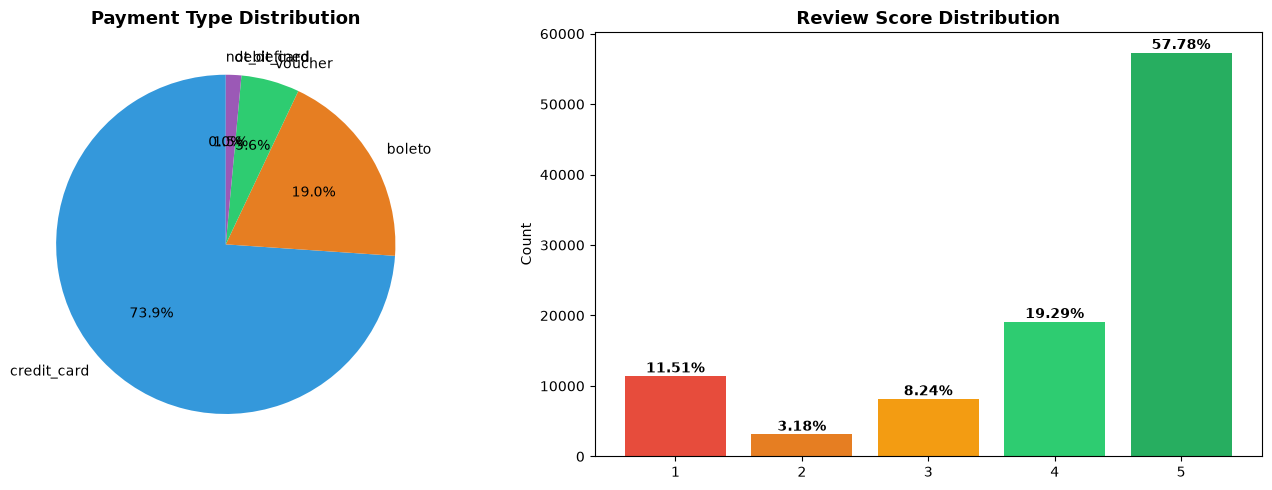

✅ 图表已保存至 reports/01_payment_review.png


In [12]:
# ============================================================
# 8. 支付方式与评价分布
# ============================================================

payment_df = con.sql("""
    SELECT payment_type, COUNT(*) as cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct,
           ROUND(AVG(payment_value), 2) as avg_value
    FROM '../data/raw/olist_order_payments_dataset.csv'
    GROUP BY payment_type ORDER BY cnt DESC
""").df()

review_df = con.sql("""
    SELECT review_score, COUNT(*) as cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct
    FROM '../data/raw/olist_order_reviews_dataset.csv'
    GROUP BY review_score ORDER BY review_score
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(payment_df['cnt'], labels=payment_df['payment_type'], autopct='%1.1f%%',
        colors=['#3498db', '#e67e22', '#2ecc71', '#9b59b6'], startangle=90)
ax1.set_title('Payment Type Distribution', fontsize=13, fontweight='bold')

score_colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60']
ax2.bar(review_df['review_score'].astype(str), review_df['cnt'], color=score_colors)
ax2.set_title('Review Score Distribution', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count')
for i, (_, row) in enumerate(review_df.iterrows()):
    ax2.text(i, row['cnt'] + 500, f"{row['pct']}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/01_payment_review.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/01_payment_review.png")

### 支付与评价解读

- **73.92%** 用信用卡支付，boleto（巴西银行票据）占 19.04%
- 评价呈 **J 型分布**：57.78% 五星 + 11.51% 一星 → 大部分体验好，但有一小部分用户遇到了严重问题
- 后续分析可以关注：1 星评价的订单有什么共同特征？（延迟送达？品类问题？特定卖家？）

In [13]:
# ============================================================
# 9. 关键业务指标汇总
# ============================================================

kpi = con.sql("""
    SELECT
        (SELECT COUNT(*) FROM '../data/raw/olist_orders_dataset.csv'
         WHERE order_status = 'delivered') as delivered_orders,
        (SELECT COUNT(DISTINCT customer_unique_id)
         FROM '../data/raw/olist_customers_dataset.csv') as unique_customers,
        (SELECT ROUND(AVG(order_total), 2) FROM (
            SELECT order_id, SUM(price) as order_total
            FROM '../data/raw/olist_order_items_dataset.csv' GROUP BY order_id)) as avg_order_value,
        (SELECT ROUND(AVG(item_cnt), 2) FROM (
            SELECT order_id, COUNT(*) as item_cnt
            FROM '../data/raw/olist_order_items_dataset.csv' GROUP BY order_id)) as avg_items_per_order
""").fetchone()

print(f"""
+====================================================================+
|                    Olist 平台关键业务指标                            |
+====================================================================+
|                                                                     |
|  订单规模                                                           |
|    * 总订单数：99,441（97.02% 送达 = {kpi[0]:,} 单）               |
|    * 时间范围：2016-09 ~ 2018-10（约 25 个月）                      |
|    * 当前月活：~6,500 单/月（2018年稳定水平）                       |
|                                                                     |
|  用户规模                                                           |
|    * 唯一用户：{kpi[1]:,}（customer_unique_id）                     |
|    * 重复购买用户：3,345（3.00%）                                  |
|    * 集中度：SP 圣保罗占 41.94%                                     |
|                                                                     |
|  交易特征                                                           |
|    * 平均客单价：R${kpi[2]:,.2f}（中位数 R$86.90）                  |
|    * 平均每单商品数：{kpi[3]}（中位数 1）                           |
|    * 主要支付方式：信用卡 73.92%                                    |
|                                                                     |
|  评价                                                               |
|    * 5星率：57.78%  |  1星率：11.51%                                |
|    * 评价分布呈 J 型（好评集中 + 差评尾巴）                         |
|                                                                     |
|  供给侧                                                             |
|    * 活跃卖家：3,095  |  商品数：32,951                             |
|    * 品类数：73  |  Top 品类：bed_bath_table / health_beauty        |
|                                                                     |
+====================================================================+
""")


+====================================================================+
|                    Olist 平台关键业务指标                            |
+====================================================================+
|                                                                     |
|  订单规模                                                           |
|    * 总订单数：99,441（97.02% 送达 = 96,478 单）               |
|    * 时间范围：2016-09 ~ 2018-10（约 25 个月）                      |
|    * 当前月活：~6,500 单/月（2018年稳定水平）                       |
|                                                                     |
|  用户规模                                                           |
|    * 唯一用户：96,096（customer_unique_id）                     |
|    * 重复购买用户：3,345（3.00%）                                  |
|    * 集中度：SP 圣保罗占 41.94%                                     |
|                                                                     |
|  交易特征                                                           |
|    * 平

In [14]:
# ============================================================
# 10. 导出业务理解报告
# ============================================================

report = f"""# Olist 电商平台业务理解报告

## 1. 平台概况

- **时间范围**：2016-09 ~ 2018-10（约 25 个月），有效运营期从 2017-01 开始
- **订单规模**：99,441 笔订单，97.02% 送达
- **用户规模**：{kpi[1]:,} 位唯一用户（customer_unique_id），月活约 6,500 单
- **供给侧**：3,095 位卖家，32,951 个商品，73 个品类

## 2. 数据关系

```
customers ----(customer_id)----> orders ----(order_id)----> order_items ----(product_id)----> products
                                   |                           +----(seller_id)----> sellers
                                   +----(order_id)----> order_payments
                                   +----(order_id)----> order_reviews
geolocation ----(zip_code_prefix)----> customers / sellers
```

## 3. 关键发现

### 3.1 品类表现
- **订单量 Top 3**：bed_bath_table (9,417)、health_beauty (8,836)、sports_leisure (7,720)
- **GMV Top 3**：health_beauty (R$1.26M)、watches_gifts (R$1.21M)、bed_bath_table (R$1.04M)
- watches_gifts 订单量仅排第 7，但 GMV 第 2 → 高客单价品类，值得关注

### 3.2 用户行为
- 复购率仅 3.00%（2,801 / 93,358），绝大多数用户只买一次
- 复购用户平均购买 2.15 次，最高 15 次
- 用户高度集中在圣保罗州（SP 占 41.94%）

### 3.3 交易特征
- 平均客单价 R${kpi[2]:,.2f}，中位数 R$86.90（右偏分布，少数大单拉高均值）
- 73.92% 用信用卡支付，boleto 占 19.04%
- 平均每单 {kpi[3]} 件商品 → 绝大多数是单件购买

### 3.4 运营效率
- 下单到送达平均 12.6 天（审批 10.3h → 揽收 2.8 天 → 运输 9.3 天）
- 评价 J 型分布：57.78% 五星，11.51% 一星

## 4. !! 关键数据陷阱

1. **customer_id != 用户**：customer_id 是订单级身份，customer_unique_id 才是真实用户
   - 用 customer_id 做复购分析 → 复购率 0%（错误）
   - 用 customer_unique_id 做复购分析 → 复购率 3.00%（正确）
2. **订单状态过滤**：漏斗和 GMV 分析时需剔除 canceled/unavailable
3. **geolocation 去重**：同一 zip_code_prefix 有多条记录，join 前需去重
4. **品类名翻译**：品类名是葡萄牙语，展示前需 join 翻译表
"""

with open('../docs/01_business_understanding.md', 'w') as f:
    f.write(report)

print("✅ 业务理解报告已导出至 docs/01_business_understanding.md")
print(f"   报告长度：{len(report):,} 字符")

con.close()
print("\n🎉 阶段 01 完成！")

✅ 业务理解报告已导出至 docs/01_business_understanding.md
   报告长度：1,515 字符

🎉 阶段 01 完成！
